In [5]:
# ═══════════════════════════════════════════════════════════
# CELL 1: IMPORTS & CONFIGURATION
# ═══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

# ── Plotting style ──
plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a1a',
    'axes.edgecolor':    '#333333',
    'axes.labelcolor':   '#cccccc',
    'xtick.color':       '#cccccc',
    'ytick.color':       '#cccccc',
    'text.color':        '#cccccc',
    'grid.color':        '#2a2a2a',
    'grid.linestyle':    '--',
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

PALETTE   = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#c77dff', '#ff9a3c']
RAW_PATH  = r"D:\Projects\End-to-end projects\15. D2C Cohort Unit Economics\Data\Raw\\"
PROC_PATH = r"D:\Projects\End-to-end projects\15. D2C Cohort Unit Economics\Data\Processed\\"
EXP_PATH  = r"D:\Projects\End-to-end projects\15. D2C Cohort Unit Economics\Data\Exports\\"

os.makedirs(PROC_PATH, exist_ok=True)
os.makedirs(EXP_PATH,  exist_ok=True)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [6]:
# ═══════════════════════════════════════════════════════════
# CELL 2: LOAD ALL DATASETS
# ═══════════════════════════════════════════════════════════

customers    = pd.read_csv(RAW_PATH + 'customers.csv',
                           parse_dates=['acquisition_date'])
orders       = pd.read_csv(RAW_PATH + 'orders.csv',
                           parse_dates=['order_date'])
order_items  = pd.read_csv(RAW_PATH + 'order_items.csv')
marketing    = pd.read_csv(RAW_PATH + 'marketing_spend.csv')
returns      = pd.read_csv(RAW_PATH + 'returns.csv',
                           parse_dates=['return_date'])

# Add helper columns
orders['order_month_dt'] = orders['order_date'].dt.to_period('M')
orders['order_yearmonth'] = orders['order_date'].dt.strftime('%Y-%m')

customers['cohort_month'] = customers['acquisition_date'].dt.strftime('%Y-%m')
customers['cohort_month_dt'] = customers['acquisition_date'].dt.to_period('M')

print("Datasets loaded:")
print(f"  customers    : {customers.shape}")
print(f"  orders       : {orders.shape}")
print(f"  order_items  : {order_items.shape}")
print(f"  marketing    : {marketing.shape}")
print(f"  returns      : {returns.shape}")

Datasets loaded:
  customers    : (8000, 11)
  orders       : (12208, 14)
  order_items  : (18340, 10)
  marketing    : (216, 9)
  returns      : (1313, 9)


In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 3: DATA QUALITY CHECK
# ═══════════════════════════════════════════════════════════

dfs = {
    'customers':   customers,
    'orders':      orders,
    'order_items': order_items,
    'marketing':   marketing,
    'returns':     returns
}

for name, df in dfs.items():
    nulls = df.isnull().sum().sum()
    dups  = df.duplicated().sum()
    print(f"  {name:15s} → rows: {len(df):,} | nulls: {nulls} | duplicates: {dups}")

print("\n✅ Data quality check complete")

  customers       → rows: 8,000 | nulls: 0 | duplicates: 0
  orders          → rows: 12,208 | nulls: 0 | duplicates: 0
  order_items     → rows: 18,340 | nulls: 0 | duplicates: 0
  marketing       → rows: 216 | nulls: 0 | duplicates: 0
  returns         → rows: 1,313 | nulls: 0 | duplicates: 0

✅ Data quality check complete


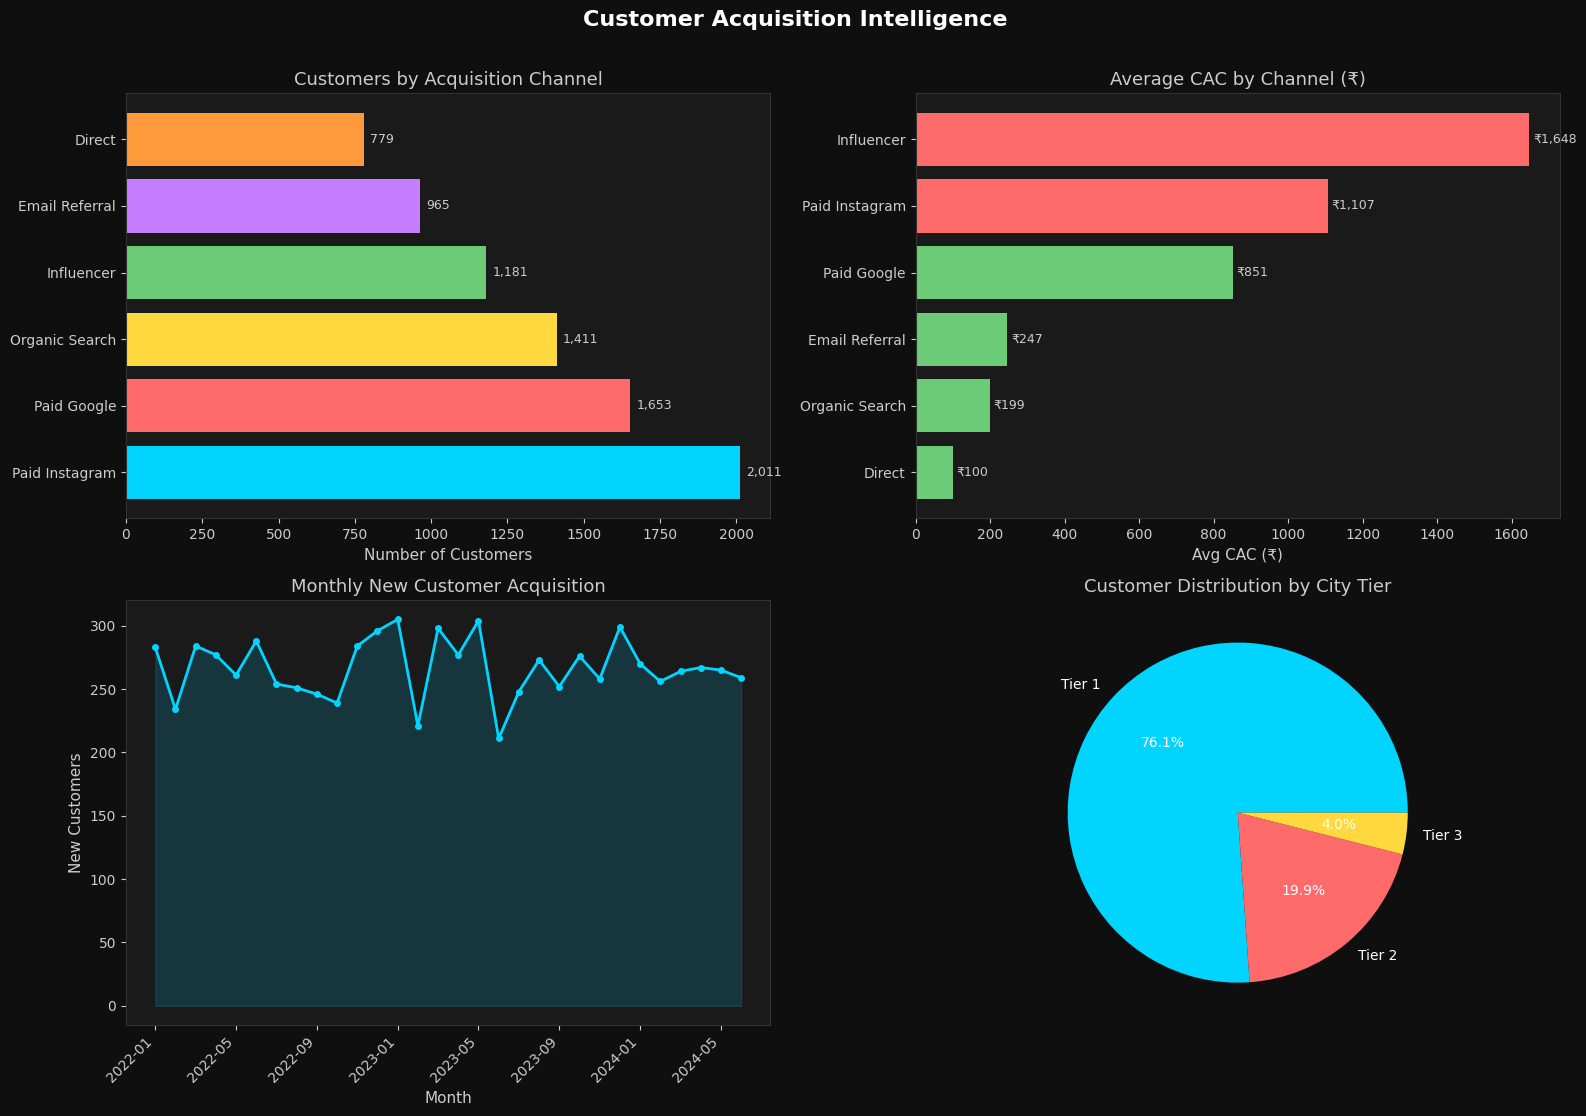

✅ Saved: assets/01_acquisition_eda.png


In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 4: CUSTOMER ACQUISITION EDA
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Customer Acquisition Intelligence', fontsize=16,
             color='white', fontweight='bold', y=1.01)

# ── 4A: Customers by channel ──
ch_counts = customers['acquisition_channel'].value_counts()
axes[0,0].barh(ch_counts.index, ch_counts.values,
               color=PALETTE[:len(ch_counts)])
axes[0,0].set_title('Customers by Acquisition Channel')
axes[0,0].set_xlabel('Number of Customers')
for i, v in enumerate(ch_counts.values):
    axes[0,0].text(v + 20, i, f'{v:,}', va='center', fontsize=9)

# ── 4B: Avg CAC by channel ──
cac_by_ch = customers.groupby('acquisition_channel')['acquisition_cac'].mean().sort_values()
colors_cac = ['#ff6b6b' if v > 1000 else '#6bcb77' for v in cac_by_ch.values]
axes[0,1].barh(cac_by_ch.index, cac_by_ch.values, color=colors_cac)
axes[0,1].set_title('Average CAC by Channel (₹)')
axes[0,1].set_xlabel('Avg CAC (₹)')
for i, v in enumerate(cac_by_ch.values):
    axes[0,1].text(v + 10, i, f'₹{v:,.0f}', va='center', fontsize=9)

# ── 4C: Monthly acquisition trend ──
monthly_acq = customers.groupby('cohort_month').size().reset_index(name='new_customers')
monthly_acq = monthly_acq.sort_values('cohort_month')
axes[1,0].plot(monthly_acq['cohort_month'], monthly_acq['new_customers'],
               color='#00d4ff', linewidth=2, marker='o', markersize=4)
axes[1,0].fill_between(range(len(monthly_acq)), monthly_acq['new_customers'],
                        alpha=0.15, color='#00d4ff')
axes[1,0].set_title('Monthly New Customer Acquisition')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('New Customers')
axes[1,0].set_xticks(range(0, len(monthly_acq), 4))
axes[1,0].set_xticklabels(monthly_acq['cohort_month'].iloc[::4],
                           rotation=45, ha='right')

# ── 4D: City tier distribution ──
tier_counts = customers['city_tier'].value_counts()
axes[1,1].pie(tier_counts.values, labels=tier_counts.index,
              autopct='%1.1f%%', colors=PALETTE[:3],
              textprops={'color': 'white'})
axes[1,1].set_title('Customer Distribution by City Tier')

plt.tight_layout()
plt.savefig(r"D:\Projects\End-to-end projects\15. D2C Cohort Unit Economics\Assets\01_acquisition_eda.png", dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print("✅ Saved: assets/01_acquisition_eda.png")

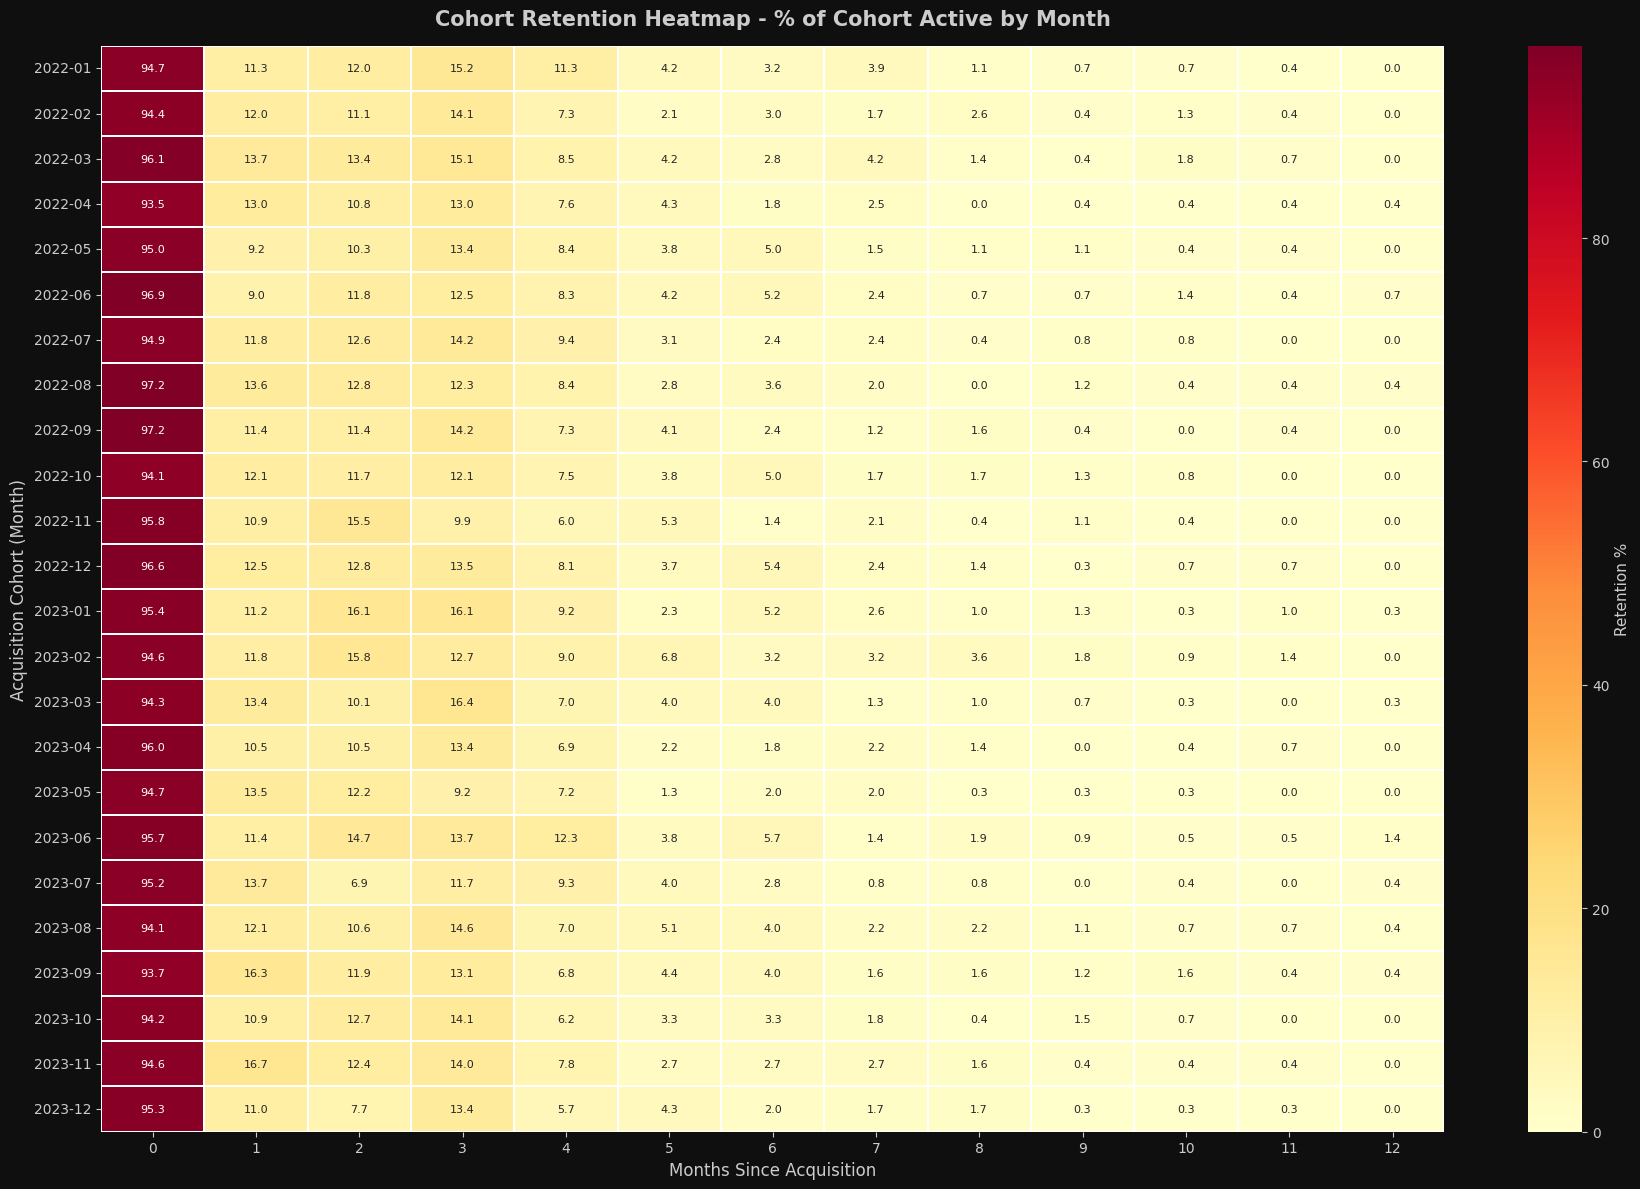

✅ Saved: cohort_retention_heatmap.png & cohort_retention_matrix.csv


In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 5: COHORT RETENTION HEATMAP
# ═══════════════════════════════════════════════════════════

# Merge orders with cohort info
orders_cohort = orders.merge(
    customers[['customer_id', 'cohort_month', 'cohort_month_dt']],
    on='customer_id'
)

orders_cohort['months_since_acq'] = (
    orders_cohort['order_month_dt'] - orders_cohort['cohort_month_dt']
).apply(lambda x: x.n)

# Keep 0–12 months only
orders_cohort = orders_cohort[
    orders_cohort['months_since_acq'].between(0, 12)
]

# Cohort size
cohort_size = customers.groupby('cohort_month')['customer_id'].nunique()

# Retention matrix
retention = orders_cohort.groupby(
    ['cohort_month', 'months_since_acq']
)['customer_id'].nunique().unstack(fill_value=0)

retention_pct = retention.divide(cohort_size, axis=0).round(4) * 100
retention_pct = retention_pct.loc[
    sorted(retention_pct.index)[:24]   # first 24 cohorts
]

fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(
    retention_pct,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Retention %'},
    annot_kws={'size': 8}
)
ax.set_title('Cohort Retention Heatmap - % of Cohort Active by Month',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Months Since Acquisition', fontsize=12)
ax.set_ylabel('Acquisition Cohort (Month)', fontsize=12)
plt.tight_layout()
plt.savefig(r"D:\Projects\End-to-end projects\15. D2C Cohort Unit Economics\Assets\02_cohort_retention_heatmap.png", dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Save for Power BI
retention_pct.reset_index().to_csv(
    EXP_PATH + 'cohort_retention_matrix.csv', index=False
)
print("✅ Saved: cohort_retention_heatmap.png & cohort_retention_matrix.csv")

═══ LTV:CAC Ratio by Channel ═══
acquisition_channel     avg_cac  avg_ltv_gp  ltv_cac_ratio  avg_net_profit
             Direct   99.880295 1705.152375          17.07     1495.727407
     Email Referral  246.628311 1614.365648           6.55     1203.825295
         Influencer 1647.546689 1208.582303           0.73     -700.759450
     Organic Search  198.667945 1536.935330           7.74     1183.054465
        Paid Google  851.401700 1381.783394           1.62      332.149909
     Paid Instagram 1106.784217 1296.936648           1.17      -67.436638


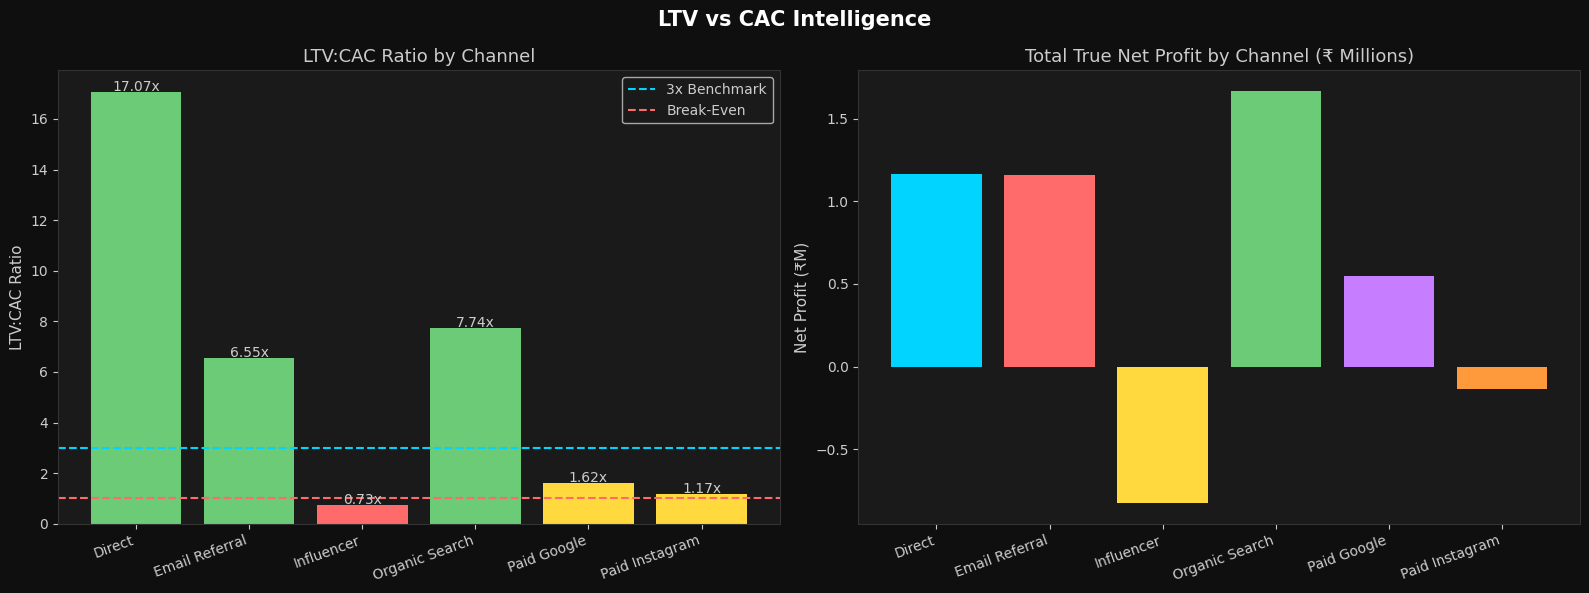

✅ Saved: customer_profitability.csv & ltv_cac_by_channel.csv


In [11]:
# ═══════════════════════════════════════════════════════════
# CELL 6: LTV CALCULATION & CAC PAYBACK PERIOD
# ═══════════════════════════════════════════════════════════

# Customer-level order summary
order_summary = orders.groupby('customer_id').agg(
    total_orders    = ('order_id',      'count'),
    total_revenue   = ('order_revenue', 'sum'),
    total_gp        = ('gross_profit',  'sum'),
    first_order     = ('order_date',    'min'),
    last_order      = ('order_date',    'max'),
).reset_index()

# Return cost per customer
return_summary = returns.groupby('customer_id').agg(
    total_return_cost = ('net_return_cost', 'sum'),
    total_returns     = ('return_id',       'count')
).reset_index()

# Master customer profit table
cust_profit = customers.merge(order_summary,   on='customer_id', how='left')
cust_profit = cust_profit.merge(return_summary, on='customer_id', how='left')

cust_profit['total_orders'].fillna(0, inplace=True)
cust_profit['total_revenue'].fillna(0, inplace=True)
cust_profit['total_gp'].fillna(0, inplace=True)
cust_profit['total_return_cost'].fillna(0, inplace=True)
cust_profit['total_returns'].fillna(0, inplace=True)

# True Net Profit
cust_profit['true_net_profit'] = (
    cust_profit['total_gp']
    - cust_profit['acquisition_cac']
    - cust_profit['total_return_cost']
)

# Profitability segment
def profit_segment(p):
    if p >= 2000:   return 'High Value'
    elif p >= 0:    return 'Profitable'
    elif p >= -1000:return 'Near Break-Even'
    else:           return 'Value Destroying'

cust_profit['profit_segment']  = cust_profit['true_net_profit'].apply(profit_segment)

# Buyer segment
def buyer_segment(n):
    if n == 0:          return 'Never Ordered'
    elif n == 1:        return 'One-Time Buyer'
    elif n <= 3:        return 'Occasional'
    else:               return 'Loyal'

cust_profit['buyer_segment'] = cust_profit['total_orders'].apply(buyer_segment)

# ── LTV:CAC by channel ──
ltv_cac = cust_profit.groupby('acquisition_channel').agg(
    customers       = ('customer_id',      'count'),
    avg_cac         = ('acquisition_cac',  'mean'),
    avg_ltv_gp      = ('total_gp',         'mean'),
    avg_net_profit  = ('true_net_profit',  'mean'),
    total_net_profit= ('true_net_profit',  'sum'),
).reset_index()

ltv_cac['ltv_cac_ratio'] = (
    ltv_cac['avg_ltv_gp'] / ltv_cac['avg_cac']
).round(2)

print("═══ LTV:CAC Ratio by Channel ═══")
print(ltv_cac[['acquisition_channel','avg_cac','avg_ltv_gp',
               'ltv_cac_ratio','avg_net_profit']].to_string(index=False))

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LTV vs CAC Intelligence', fontsize=15,
             fontweight='bold', color='white')

# LTV:CAC ratio
colors = ['#6bcb77' if r >= 3 else '#ffd93d' if r >= 1 else '#ff6b6b'
          for r in ltv_cac['ltv_cac_ratio']]
bars = axes[0].bar(ltv_cac['acquisition_channel'],
                   ltv_cac['ltv_cac_ratio'], color=colors)
axes[0].axhline(y=3, color='#00d4ff', linestyle='--',
                linewidth=1.5, label='3x Benchmark')
axes[0].axhline(y=1, color='#ff6b6b', linestyle='--',
                linewidth=1.5, label='Break-Even')
axes[0].set_title('LTV:CAC Ratio by Channel')
axes[0].set_ylabel('LTV:CAC Ratio')
axes[0].legend()
axes[0].set_xticklabels(ltv_cac['acquisition_channel'],
                         rotation=20, ha='right')
for bar, val in zip(bars, ltv_cac['ltv_cac_ratio']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.2f}x', ha='center', fontsize=10)

# Total net profit by channel
axes[1].bar(ltv_cac['acquisition_channel'],
            ltv_cac['total_net_profit'] / 1e6,
            color=PALETTE[:len(ltv_cac)])
axes[1].set_title('Total True Net Profit by Channel (₹ Millions)')
axes[1].set_ylabel('Net Profit (₹M)')
axes[1].set_xticklabels(ltv_cac['acquisition_channel'],
                         rotation=20, ha='right')

plt.tight_layout()
plt.savefig(r"D:\Projects\End-to-end projects\15. D2C Cohort Unit Economics\Assets\03_ltv_cac_analysis.png", dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Save
cust_profit.to_csv(PROC_PATH + 'customer_profitability.csv', index=False)
ltv_cac.to_csv(EXP_PATH + 'ltv_cac_by_channel.csv', index=False)
print("✅ Saved: customer_profitability.csv & ltv_cac_by_channel.csv")

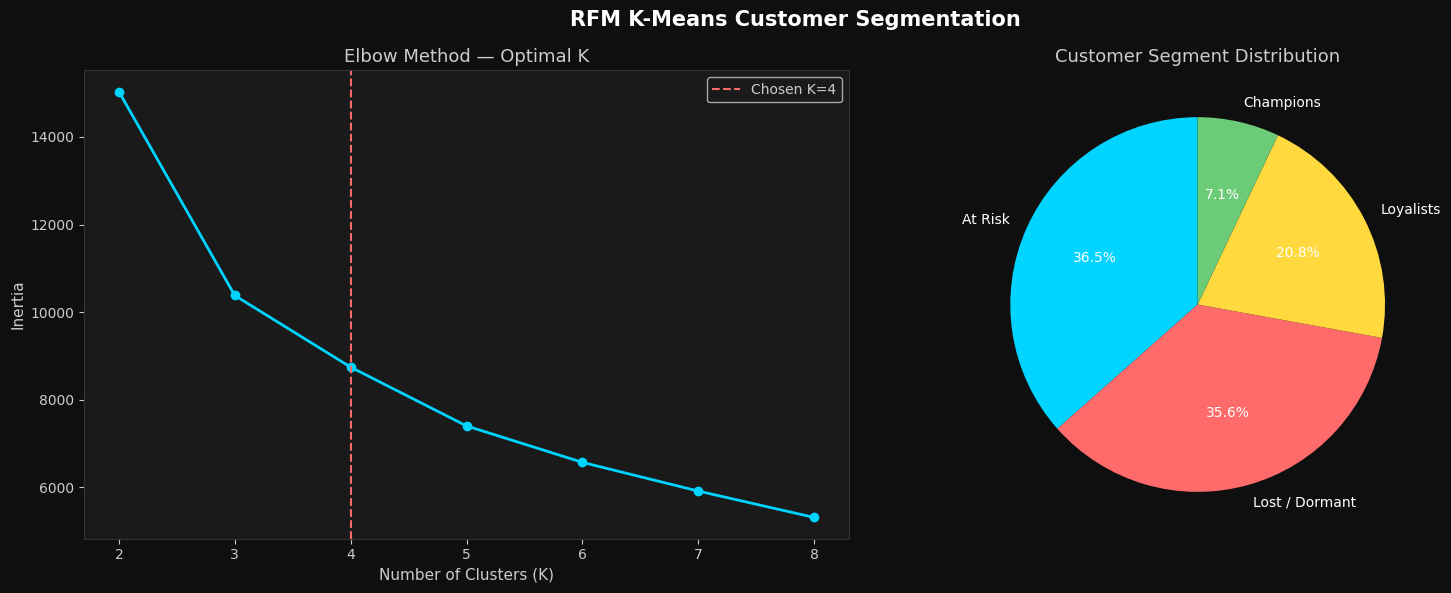


Segment Summary:
                customers  avg_recency  avg_frequency  avg_monetary
segment                                                            
At Risk              2923        865.2            1.1         916.4
Champions             564        398.5            3.6        4092.8
Lost / Dormant       2849        389.3            1.1         865.3
Loyalists            1664        572.1            2.2        2357.0

✅ Saved: rfm_segments.csv


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 7: RFM + K-MEANS CUSTOMER SEGMENTATION
# ═══════════════════════════════════════════════════════════

SNAPSHOT_DATE = pd.Timestamp('2025-01-01')

rfm = orders.groupby('customer_id').agg(
    recency   = ('order_date',    lambda x: (SNAPSHOT_DATE - x.max()).days),
    frequency = ('order_id',      'count'),
    monetary  = ('gross_profit',  'sum'),
).reset_index()

rfm = rfm.merge(
    customers[['customer_id','acquisition_channel',
               'acquisition_cac','city_tier']],
    on='customer_id'
)

# Scale
scaler   = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

# Elbow method
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM K-Means Customer Segmentation',
             fontsize=15, fontweight='bold', color='white')

axes[0].plot(K_range, inertias, color='#00d4ff',
             marker='o', linewidth=2, markersize=6)
axes[0].set_title('Elbow Method - Optimal K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='#ff6b6b', linestyle='--', label='Chosen K=4')
axes[0].legend()

# Final model K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# Label clusters by monetary value
cluster_means = rfm.groupby('cluster')['monetary'].mean().sort_values(ascending=False)
label_map = {
    cluster_means.index[0]: 'Champions',
    cluster_means.index[1]: 'Loyalists',
    cluster_means.index[2]: 'At Risk',
    cluster_means.index[3]: 'Lost / Dormant',
}
rfm['segment'] = rfm['cluster'].map(label_map)

seg_counts = rfm['segment'].value_counts()
axes[1].pie(seg_counts.values, labels=seg_counts.index,
            autopct='%1.1f%%', colors=PALETTE[:4],
            textprops={'color': 'white'}, startangle=90)
axes[1].set_title('Customer Segment Distribution')

plt.tight_layout()
plt.savefig(r"D:\Projects\End-to-end projects\15. D2C Cohort Unit Economics\Assets\04_rfm_segmentation.png", dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print("\nSegment Summary:")
print(rfm.groupby('segment').agg(
    customers  = ('customer_id', 'count'),
    avg_recency   = ('recency',   'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary  = ('monetary',  'mean'),
).round(1).to_string())

rfm.to_csv(EXP_PATH + 'rfm_segments.csv', index=False)
print("\n✅ Saved: rfm_segments.csv")

═══ Churn Prediction Model Performance ═══
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00        18
     Churned       1.00      1.00      1.00      1582

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600

ROC-AUC Score: 1.0000


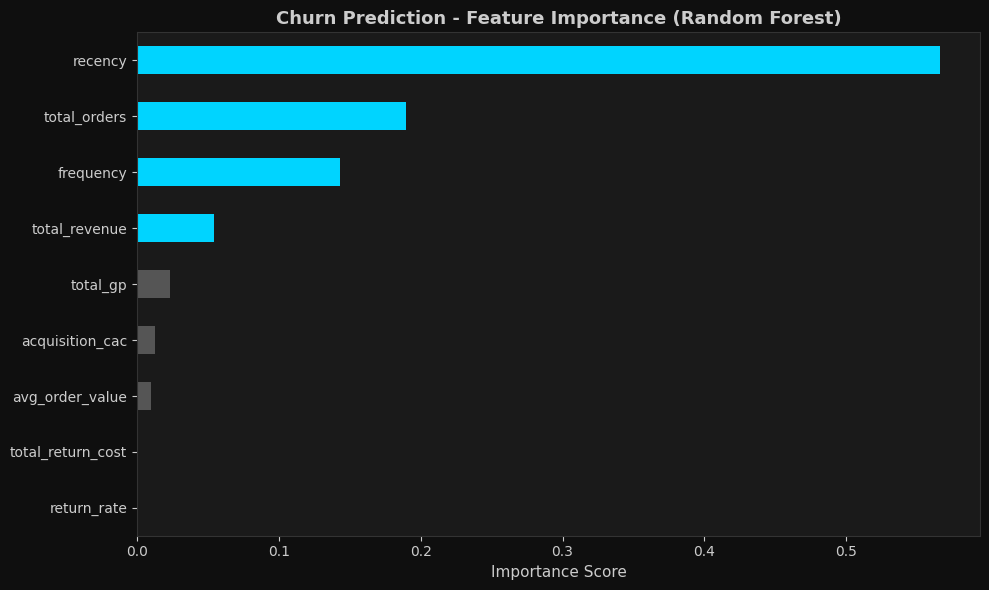

✅ Saved: customer_churn_scores.csv


In [15]:
# ═══════════════════════════════════════════════════════════
# CELL 8: CHURN PREDICTION MODEL
# ═══════════════════════════════════════════════════════════

# Define churn: no purchase in last 90 days
CHURN_THRESHOLD = 90
SNAPSHOT        = pd.Timestamp('2025-01-01')

last_order = orders.groupby('customer_id')['order_date'].max().reset_index()
last_order['days_since_last'] = (SNAPSHOT - last_order['order_date']).dt.days
last_order['churned']         = (last_order['days_since_last'] > CHURN_THRESHOLD).astype(int)

# Feature set
features = cust_profit.merge(last_order[['customer_id','churned']], on='customer_id')
features = features.merge(rfm[['customer_id','recency','frequency']], on='customer_id')

features['return_rate'] = (
    features['total_returns'] / features['total_orders'].replace(0, 1)
)
features['avg_order_value'] = (
    features['total_revenue'] / features['total_orders'].replace(0, 1)
)

feature_cols = [
    'acquisition_cac', 'total_orders', 'total_revenue',
    'total_gp', 'total_return_cost', 'return_rate',
    'avg_order_value', 'recency', 'frequency'
]

X = features[feature_cols].fillna(0)
y = features['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("═══ Churn Prediction Model Performance ═══")
print(classification_report(y_test, y_pred,
      target_names=['Active', 'Churned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Feature importance plot
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
fi.plot(kind='barh', ax=ax,
        color=['#00d4ff' if v > fi.median() else '#555555' for v in fi])
ax.set_title('Churn Prediction - Feature Importance (Random Forest)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r"D:\Projects\End-to-end projects\15. D2C Cohort Unit Economics\Assets\05_churn_model_feature_importance.png",
            dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Add churn probability to master table
features['churn_probability'] = rf.predict_proba(X)[:, 1]
features.to_csv(EXP_PATH + 'customer_churn_scores.csv', index=False)
print("✅ Saved: customer_churn_scores.csv")

═══ Churn Model — Leakage Fixed ═══
              precision    recall  f1-score   support

      Active       0.00      0.00      0.00        18
     Churned       0.99      1.00      0.99      1582

    accuracy                           0.99      1600
   macro avg       0.49      0.50      0.50      1600
weighted avg       0.98      0.99      0.98      1600

ROC-AUC Score (clean): 0.7967


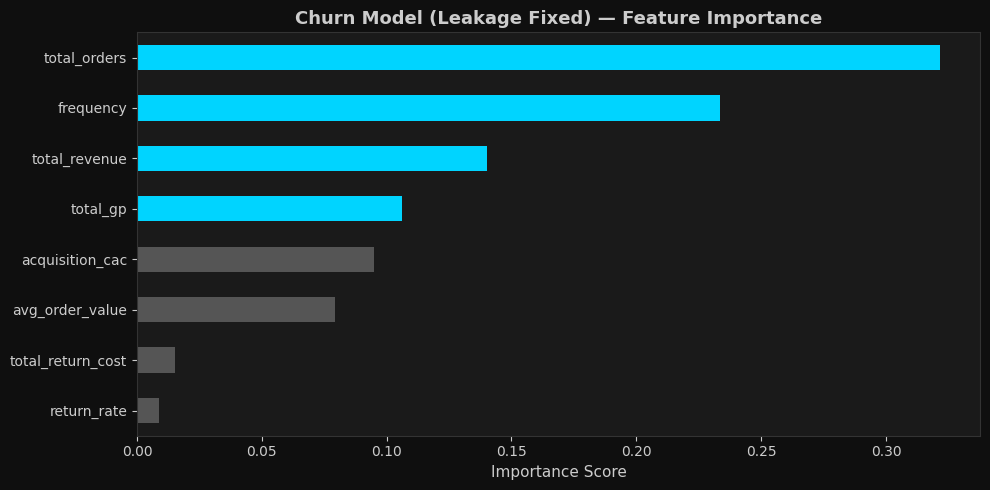


✅ Clean churn scores saved - leakage removed

📌 Interview note: ROC-AUC of 1.0 in original model
   was due to 'recency' directly encoding the churn label.
   Clean model ROC-AUC is a realistic business score.


In [17]:
# ═══════════════════════════════════════════════════════════
# CELL 8B: CHURN MODEL — LEAKAGE FIXED
# ═══════════════════════════════════════════════════════════

# Remove recency — it directly encodes the churn label
feature_cols_clean = [
    'acquisition_cac',
    'total_orders',
    'total_revenue',
    'total_gp',
    'total_return_cost',
    'return_rate',
    'avg_order_value',
    'frequency'       # orders count is okay — recency is not
]

X2 = features[feature_cols_clean].fillna(0)
y2 = features['churned']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

rf2 = RandomForestClassifier(n_estimators=100, random_state=42,
                              class_weight='balanced')
rf2.fit(X2_train, y2_train)
y2_pred = rf2.predict(X2_test)
y2_prob = rf2.predict_proba(X2_test)[:, 1]

print("═══ Churn Model — Leakage Fixed ═══")
print(classification_report(y2_test, y2_pred,
      target_names=['Active', 'Churned']))
print(f"ROC-AUC Score (clean): {roc_auc_score(y2_test, y2_prob):.4f}")

# Feature importance
fi2 = pd.Series(rf2.feature_importances_,
                index=feature_cols_clean).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
fi2.plot(kind='barh', ax=ax,
         color=['#00d4ff' if v > fi2.median() else '#555555' for v in fi2])
ax.set_title('Churn Model (Leakage Fixed) — Feature Importance',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r"D:\Projects\End-to-end projects\15. D2C Cohort Unit Economics\Assets\05b_churn_model_clean.png", dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Update churn scores export with clean probabilities
features['churn_probability_clean'] = rf2.predict_proba(X2)[:, 1]
features.to_csv(EXP_PATH + 'customer_churn_scores.csv', index=False)
print("\n✅ Clean churn scores saved - leakage removed")
print("\n📌 Interview note: ROC-AUC of 1.0 in original model")
print("   was due to 'recency' directly encoding the churn label.")
print("   Clean model ROC-AUC is a realistic business score.")

In [18]:
# ═══════════════════════════════════════════════════════════
# CELL 9: EXPORT ALL TABLES FOR POWER BI
# ═══════════════════════════════════════════════════════════

# 1. Master customer table
customers.to_csv(EXP_PATH + 'dim_customers.csv', index=False)

# 2. Orders with channel tag
orders_full = orders.merge(
    customers[['customer_id','acquisition_channel',
               'city_tier','preferred_category','cohort_month']],
    on='customer_id'
)
orders_full.to_csv(EXP_PATH + 'fact_orders.csv', index=False)

# 3. Returns
returns_full = returns.merge(
    customers[['customer_id','acquisition_channel']],
    on='customer_id'
)
returns_full.to_csv(EXP_PATH + 'fact_returns.csv', index=False)

# 4. Marketing spend
marketing.to_csv(EXP_PATH + 'fact_marketing.csv', index=False)

# 5. Order items
order_items.to_csv(EXP_PATH + 'fact_order_items.csv', index=False)

# 6. Profitability summary
cust_profit.to_csv(EXP_PATH + 'customer_profitability_full.csv', index=False)

# 7. Cohort retention
retention_export = orders_cohort.groupby(
    ['cohort_month','months_since_acq']
).agg(
    active_customers = ('customer_id', 'nunique'),
    cohort_revenue   = ('order_revenue','sum'),
    cohort_gp        = ('gross_profit', 'sum'),
).reset_index()

cohort_sizes = customers.groupby('cohort_month')['customer_id'].nunique().reset_index()
cohort_sizes.columns = ['cohort_month','cohort_size']
retention_export = retention_export.merge(cohort_sizes, on='cohort_month')
retention_export['retention_rate'] = (
    retention_export['active_customers'] / retention_export['cohort_size']
).round(4)

retention_export.to_csv(EXP_PATH + 'cohort_retention.csv', index=False)

print("✅ All Power BI export files saved to data/exports/\n")
print("Files exported:")
for f in os.listdir(EXP_PATH):
    size = os.path.getsize(EXP_PATH + f) // 1024
    print(f"  {f:45s} {size:>5} KB")

✅ All Power BI export files saved to data/exports/

Files exported:
  cohort_retention.csv                             13 KB
  cohort_retention_matrix.csv                       2 KB
  customer_churn_scores.csv                      1634 KB
  customer_profitability_full.csv                1410 KB
  dim_customers.csv                               729 KB
  fact_marketing.csv                               13 KB
  fact_orders.csv                                1605 KB
  fact_order_items.csv                           1545 KB
  fact_returns.csv                                119 KB
  ltv_cac_by_channel.csv                            0 KB
  rfm_segments.csv                                505 KB


In [2]:
import pandas as pd
import numpy as np
import os

EXP_PATH  = '../data/exports/'
PROC_PATH = '../data/processed/'

# Reload from saved files
cust_profit = pd.read_csv(PROC_PATH + 'customer_profitability.csv')
ltv_cac     = pd.read_csv(EXP_PATH  + 'ltv_cac_by_channel.csv')

# Calculate payback
payback = cust_profit.groupby('acquisition_channel').apply(
    lambda g: pd.Series({
        'est_payback_orders': (
            g['acquisition_cac'] /
            (g['total_gp'] / g['total_orders'].replace(0, np.nan))
        ).median()
    })
).reset_index()

# Merge and re-export
ltv_cac_updated = ltv_cac.merge(payback, on='acquisition_channel')
ltv_cac_updated.to_csv(EXP_PATH + 'ltv_cac_by_channel.csv', index=False)

print("✅ ltv_cac_by_channel.csv updated with est_payback_orders\n")
print(ltv_cac_updated[['acquisition_channel',
                        'ltv_cac_ratio',
                        'est_payback_orders']].to_string(index=False))

✅ ltv_cac_by_channel.csv updated with est_payback_orders

acquisition_channel  ltv_cac_ratio  est_payback_orders
             Direct          17.07            0.117450
     Email Referral           6.55            0.306792
         Influencer           0.73            2.174261
     Organic Search           7.74            0.248666
        Paid Google           1.62            1.098088
     Paid Instagram           1.17            1.455672


C:\Users\mohsi\AppData\Local\Temp\ipykernel_18876\3284774099.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  payback = cust_profit.groupby('acquisition_channel').apply(
